In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Vehicle_Insurance.csv')

In [14]:
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [18]:
df.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


In [20]:
df.dtypes

id                        int64
Gender                   object
Age                       int64
Driving_License           int64
Region_Code             float64
Previously_Insured        int64
Vehicle_Age              object
Vehicle_Damage           object
Annual_Premium          float64
Policy_Sales_Channel    float64
Vintage                   int64
Response                  int64
dtype: object

In [22]:
# 3. DATA CLEANING

df.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [24]:
# No missing values in dataset
# Check duplicates
df.drop_duplicates(inplace=True)

In [26]:
# Outlier handling

Q1 = df['Annual_Premium'].quantile(0.25)
Q3 = df['Annual_Premium'].quantile(0.75)
IQR = Q3 - Q1


df = df[(df['Annual_Premium'] >= Q1 - 1.5 * IQR) & (df['Annual_Premium'] <= Q3 + 1.5 * IQR)]

In [48]:
# 4. TARGET VARIABLE ANALYSIS

claim_counts = df['Response'].value_counts()
claim_counts

Response
0    325634
1     45155
Name: count, dtype: int64

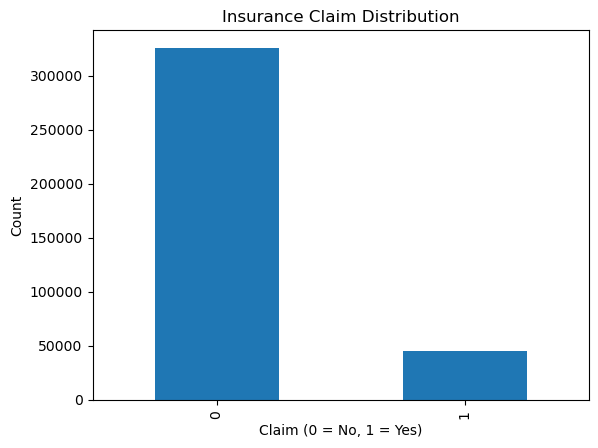

In [30]:
plt.figure()
claim_counts.plot(kind='bar')
plt.title('Insurance Claim Distribution')
plt.xlabel('Claim (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

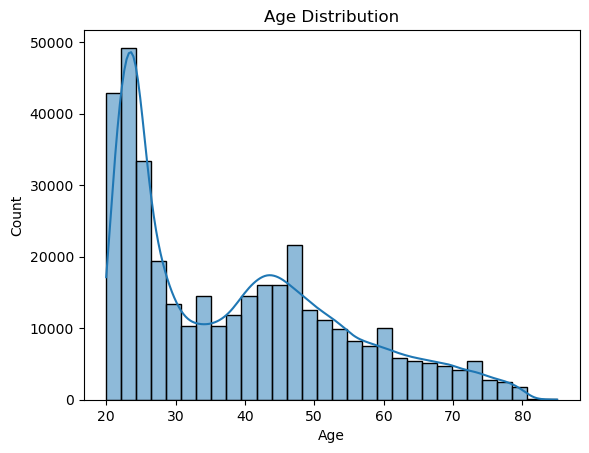

In [32]:
# 5. AGE DISTRIBUTION & CLAIM IMPACT

plt.figure()
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

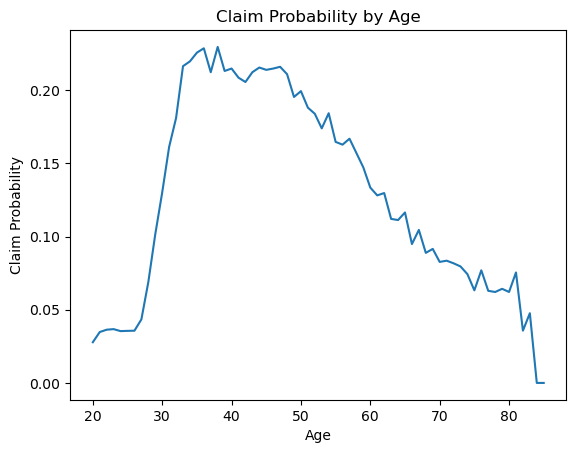

In [34]:
age_claim = df.groupby('Age')['Response'].mean()
plt.figure()
age_claim.plot()
plt.title('Claim Probability by Age')
plt.xlabel('Age')
plt.ylabel('Claim Probability')
plt.show()

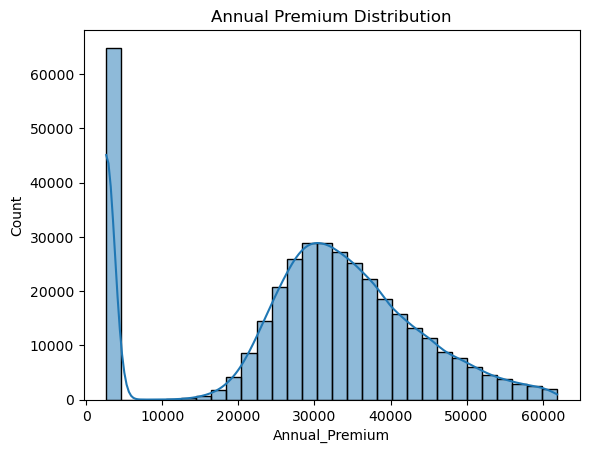

In [36]:
# 6. PREMIUM ANALYSIS

plt.figure()
sns.histplot(df['Annual_Premium'], bins=30, kde=True)
plt.title('Annual Premium Distribution')
plt.show()

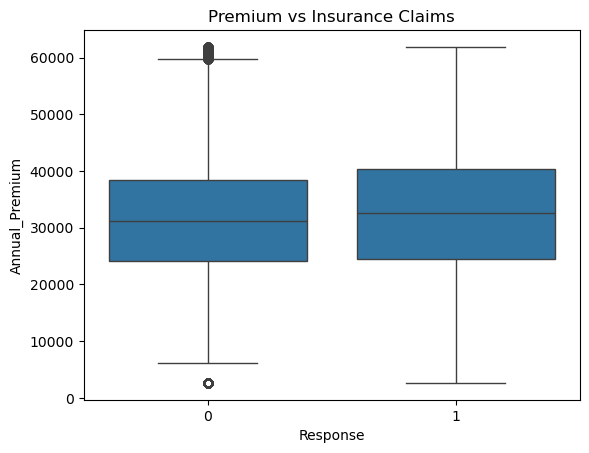

In [38]:
plt.figure()
sns.boxplot(x='Response', y='Annual_Premium', data=df)
plt.title('Premium vs Insurance Claims')
plt.show()

In [50]:
# 7. CLAIM FREQUENCY FACTORS

prev_insured_claim = pd.crosstab(df['Previously_Insured'], df['Response'], normalize='index')
prev_insured_claim

Response,0,1
Previously_Insured,,
0,0.775388,0.224612
1,0.999096,0.000904


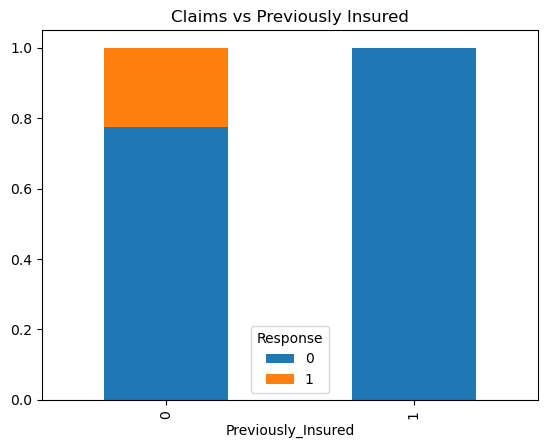

In [42]:
prev_insured_claim.plot(kind='bar', stacked=True)
plt.title('Claims vs Previously Insured')
plt.show()

In [46]:
# 8. GENDER ANALYSIS

gender_claim = pd.crosstab(df['Gender'], df['Response'], normalize='index')
gender_claim

Response,0,1
Gender,,
Female,0.896762,0.103238
Male,0.862439,0.137561


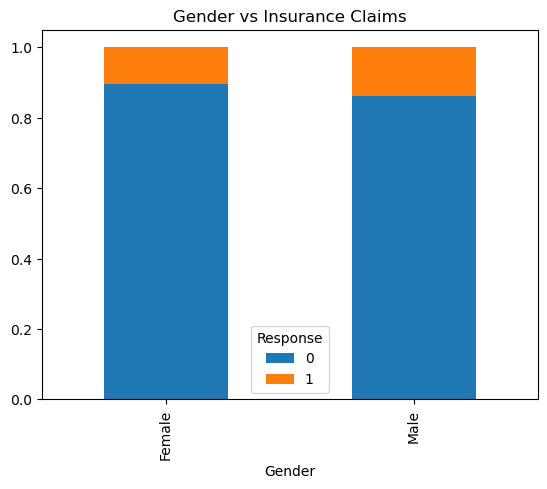

In [52]:
gender_claim.plot(kind='bar', stacked=True)
plt.title('Gender vs Insurance Claims')
plt.show()

In [58]:
# 9. VEHICLE AGE & CLAIMS

vehicle_age_claim = pd.crosstab(df['Vehicle_Age'], df['Response'], normalize='index')
vehicle_age_claim

Response,0,1
Vehicle_Age,,
1-2 Year,0.826247,0.173753
< 1 Year,0.956298,0.043702
> 2 Years,0.710579,0.289421


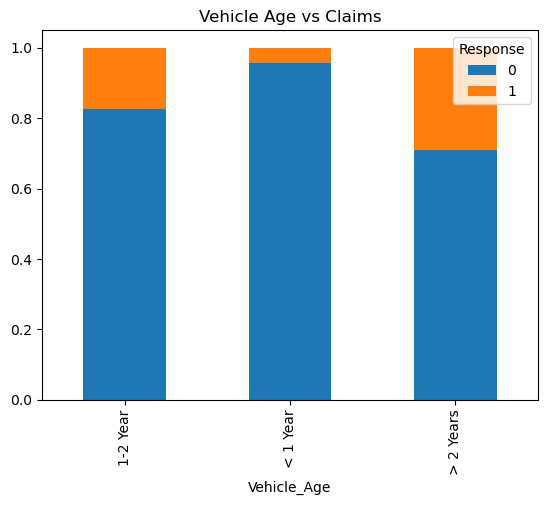

In [56]:
vehicle_age_claim.plot(kind='bar', stacked=True)
plt.title('Vehicle Age vs Claims')
plt.show()

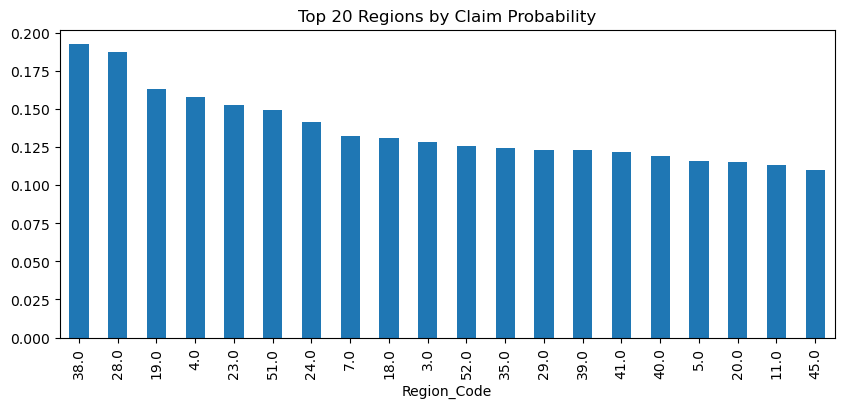

In [60]:
# 10. REGION-WISE ANALYSIS

region_claim = df.groupby('Region_Code')['Response'].mean().sort_values(ascending=False)


plt.figure(figsize=(10,4))
region_claim.head(20).plot(kind='bar')
plt.title('Top 20 Regions by Claim Probability')
plt.show()

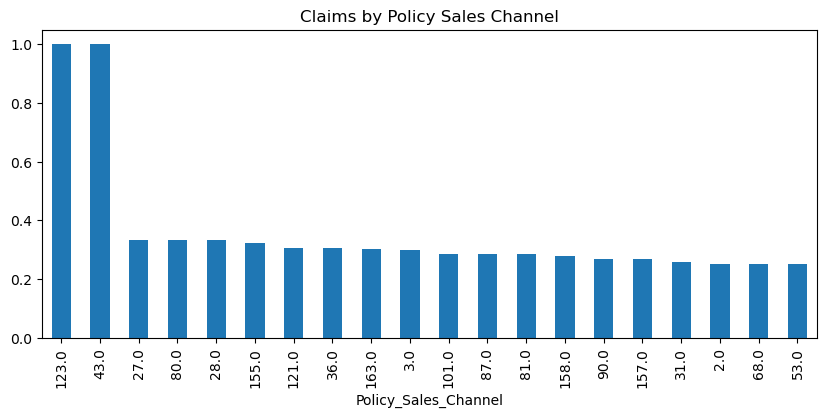

In [62]:
# 11. POLICY SALES CHANNEL ANALYSIS

policy_claim = df.groupby('Policy_Sales_Channel')['Response'].mean().sort_values(ascending=False)


plt.figure(figsize=(10,4))
policy_claim.head(20).plot(kind='bar')
plt.title('Claims by Policy Sales Channel')
plt.show()

Response               0         1
Vehicle_Damage                    
No              0.994751  0.005249
Yes             0.763144  0.236856


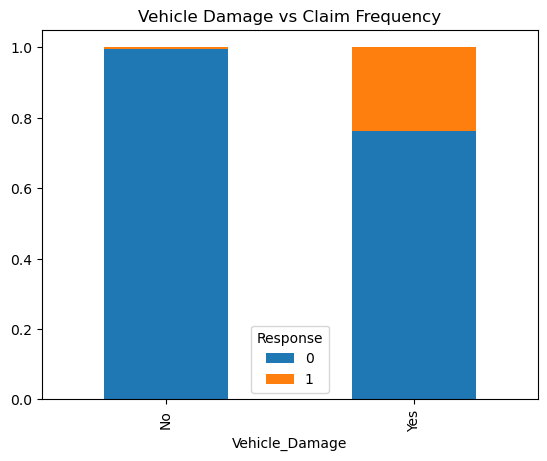

In [64]:
# 12. VEHICLE DAMAGE & CLAIM FREQUENCY

vehicle_damage_claim = pd.crosstab(df['Vehicle_Damage'], df['Response'], normalize='index')
print(vehicle_damage_claim)


vehicle_damage_claim.plot(kind='bar', stacked=True)
plt.title('Vehicle Damage vs Claim Frequency')
plt.show()

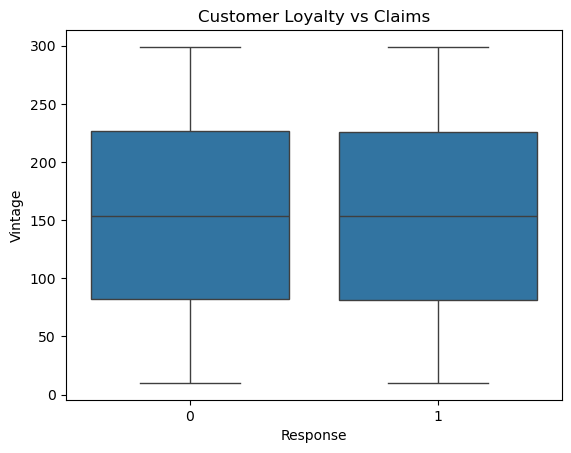

In [66]:
# 13. CUSTOMER LOYALTY (VINTAGE) ANALYSIS

plt.figure()
sns.boxplot(x='Response', y='Vintage', data=df)
plt.title('Customer Loyalty vs Claims')
plt.show()

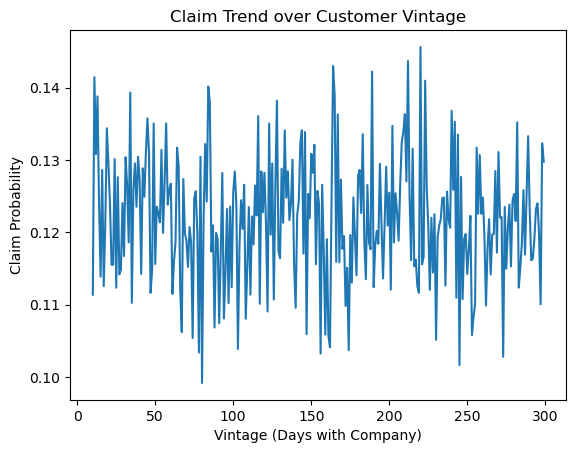

In [68]:
# 14. TIME-BASED ANALYSIS (VINTAGE)

vintage_claim = df.groupby('Vintage')['Response'].mean()


plt.figure()
vintage_claim.plot()
plt.title('Claim Trend over Customer Vintage')
plt.xlabel('Vintage (Days with Company)')
plt.ylabel('Claim Probability')
plt.show()

# KEY INSIGHTS

- Older vehicles show higher claim probability
- Customers with vehicle damage are more likely to claim
- Previously insured customers file fewer claims
- Premium amount has weak correlation with claims
- Certain regions show higher claim frequencies